# Historical experiment snapshot

Saved outputs from the source Colab, not rerun during packaging. See RESULTS.md
for protocol limitations and metric provenance. Use traffic_forecasting.ipynb for new runs.
Authors: Sergey Kokorev, Nikita Kuznetsov, Georgy Uspensky.


In [104]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [105]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sb
from matplotlib import colors
import numpy as np

In [106]:
sb.set(rc={"axes.facecolor":"#FFF9ED","figure.facecolor":"#FFF9ED"})
pallet = ["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"]
cmap = colors.ListedColormap(["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"])

In [107]:
DATA = pd.read_csv("/content/drive/MyDrive/Metro_Interstate_Traffic_Volume.csv")

In [108]:
DATA.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [109]:
DATA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [110]:
data = DATA.copy()
data['date_time'] = pd.to_datetime(data['date_time'])

dt = data['date_time']
day = dt.dt.normalize()

data['sin_hour'] = np.sin(2 * np.pi * dt.dt.hour / 24)
data['cos_hour'] = np.cos(2 * np.pi * dt.dt.hour / 24)

data['sin_weekday'] = np.sin(2 * np.pi * dt.dt.weekday / 7)
data['cos_weekday'] = np.cos(2 * np.pi * dt.dt.weekday / 7)

data['sin_month'] = np.sin(2 * np.pi * (dt.dt.month - 1) / 12)
data['cos_month'] = np.cos(2 * np.pi * (dt.dt.month - 1) / 12)

data['holiday'] = data['holiday'].fillna('no')
data['is_holiday'] = (
    data['holiday']
    .replace(['None', 'no', ''], np.nan)
    .groupby(day)
    .transform(lambda s: int(s.notna().any()))
    .astype('int8')
)

#data.drop(columns=['weather_description', 'date_time', 'holiday'], inplace=True)

data

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,sin_hour,cos_hour,sin_weekday,cos_weekday,sin_month,cos_month,is_holiday
0,no,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,7.071068e-01,-0.707107,0.781831,0.62349,-1.000000,-1.836970e-16,0
1,no,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,5.000000e-01,-0.866025,0.781831,0.62349,-1.000000,-1.836970e-16,0
2,no,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,2.588190e-01,-0.965926,0.781831,0.62349,-1.000000,-1.836970e-16,0
3,no,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,1.224647e-16,-1.000000,0.781831,0.62349,-1.000000,-1.836970e-16,0
4,no,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,-2.588190e-01,-0.965926,0.781831,0.62349,-1.000000,-1.836970e-16,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,no,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543,-9.659258e-01,0.258819,-0.781831,0.62349,-0.866025,-5.000000e-01,0
48200,no,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781,-8.660254e-01,0.500000,-0.781831,0.62349,-0.866025,-5.000000e-01,0
48201,no,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159,-7.071068e-01,0.707107,-0.781831,0.62349,-0.866025,-5.000000e-01,0
48202,no,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450,-5.000000e-01,0.866025,-0.781831,0.62349,-0.866025,-5.000000e-01,0


In [111]:
num_cols = ['is_holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume', 'sin_hour', 'cos_hour', 'sin_weekday', 'cos_weekday', 'sin_month', 'cos_month']

In [112]:
data.describe()

,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume,sin_hour,cos_hour,sin_weekday,cos_weekday,sin_month,cos_month,is_holiday
count,48204.000000,48204.000000,48204.000000,48204.000000,48204,48204.000000,4.820400e+04,4.820400e+04,48204.000000,48204.000000,4.820400e+04,4.820400e+04,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,2016-01-05 10:46:16.773711616,3259.818355,1.428336e-02,6.631123e-03,0.001410,0.005435,1.531222e-02,-3.127872e-02,0.029230
min,0.000000,0.000000,0.000000,0.000000,2012-10-02 09:00:00,0.000000,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,0.000000
25%,272.160000,0.000000,0.000000,1.000000,2014-02-06 11:45:00,1193.000000,-7.071068e-01,-7.071068e-01,-0.781831,-0.900969,-5.000000e-01,-8.660254e-01,0.000000
50%,282.450000,0.000000,0.000000,64.000000,2016-06-11 03:30:00,3380.000000,1.224647e-16,6.123234e-17,0.000000,-0.222521,1.224647e-16,-1.836970e-16,0.000000
75%,291.806000,0.000000,0.000000,90.000000,2017-08-11 06:00:00,4933.000000,7.071068e-01,7.071068e-01,0.781831,0.623490,8.660254e-01,5.000000e-01,0.000000
max,310.070000,9831.300000,0.510000,100.000000,2018-09-30 23:00:00,7280.000000,1.000000e+00,1.000000e+00,0.974928,1.000000,1.000000e+00,1.000000e+00,1.000000
std,13.338232,44.789133,0.008168,39.015750,NaN,1986.860670,7.084205e-01,7.056296e-01,0.706131,0.708073,6.983975e-01,7.148768e-01,0.168452


Data clear

In [113]:
data = data[data['rain_1h'] < 40]

In [114]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['weather_main'] = le.fit_transform(data['weather_main'])


/tmp/ipykernel_17293/3178415853.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['weather_main'] = le.fit_transform(data['weather_main'])


In [115]:
feature_cols = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'is_holiday',
    'sin_hour',
    'cos_hour',
    'sin_weekday',
    'cos_weekday',
    'sin_month',
    'cos_month',
    'weather_main',
    'traffic_volume'
]

target = 'traffic_volume'

In [116]:
data = data.sort_values('date_time').reset_index(drop=True)

n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = data.iloc[:train_end].copy()
val_df = data.iloc[train_end:val_end].copy()
test_df = data.iloc[val_end:].copy()

In [117]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

train_X_tab = scaler_X.fit_transform(train_df[feature_cols])
val_X_tab = scaler_X.transform(val_df[feature_cols])
test_X_tab = scaler_X.transform(test_df[feature_cols])

train_y_tab = scaler_y.fit_transform(train_df[[target]])
val_y_tab = scaler_y.transform(val_df[[target]])
test_y_tab = scaler_y.transform(test_df[[target]])

In [118]:
def make_sequences(X, y, window_size):
    X_seq, y_seq = [], []

    for i in range(len(X) - window_size):
        X_seq.append(X[i:i + window_size])
        y_seq.append(y[i + window_size])

    return np.array(X_seq), np.array(y_seq)

In [119]:
window_size = 24

X_train, y_train = make_sequences(train_X_tab, train_y_tab, window_size)
X_val, y_val = make_sequences(val_X_tab, val_y_tab, window_size)
X_test, y_test = make_sequences(test_X_tab, test_y_tab, window_size)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(33716, 24, 13) (33716, 1)
(7206, 24, 13) (7206, 1)
(7207, 24, 13) (7207, 1)


In [120]:
import torch
from torch.utils.data import Dataset, DataLoader

class TrafficDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [121]:
batch_size = 64

train_dataset = TrafficDataset(X_train, y_train)
val_dataset = TrafficDataset(X_val, y_val)
test_dataset = TrafficDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [122]:
import torch.nn as nn

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, (h_n, c_n) = self.lstm(x)

        # берём выход последнего шага по времени
        last_output = out[:, -1, :]   # shape: (batch, hidden_size)
        y_pred = self.fc(last_output) # shape: (batch, 1)

        return y_pred

In [123]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

input_size = X_train.shape[2]

model = LSTMRegressor(
    input_size=input_size,
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(device)

cuda


In [124]:
def train(model, loader, criterion, optimizer, device, l1_lambda=0.0):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)

        if l1_lambda > 0:
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [125]:
@torch.no_grad()
def val(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [126]:
import torch.optim as optim

class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.gru(x)

        last_output = out[:, -1, :]   # shape: (batch, hidden_size)
        y_pred = self.fc(last_output) # shape: (batch, 1)

        return y_pred

In [127]:
@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch)

        preds.append(y_pred.cpu().numpy())
        targets.append(y_batch.numpy())

    preds = np.vstack(preds)
    targets = np.vstack(targets)

    return preds, targets

LSTM | SGD | Without reg
LSTM | SGD | L1 (1e-4)
LSTM | SGD | L2 (1e-4)


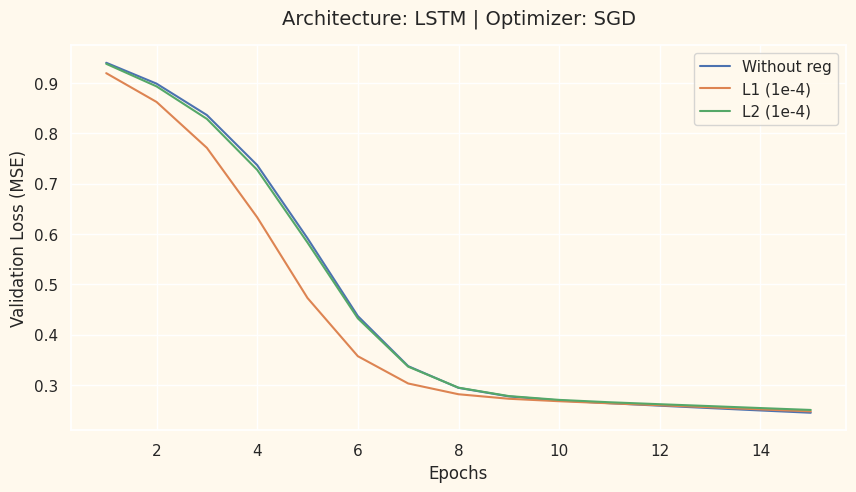

LSTM | Momentum | Without reg
LSTM | Momentum | L1 (1e-4)
LSTM | Momentum | L2 (1e-4)


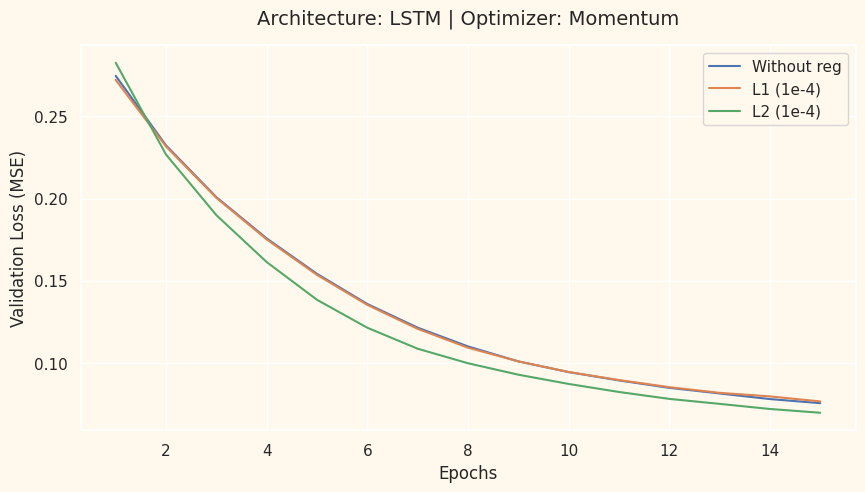

LSTM | RMSProp | Without reg
LSTM | RMSProp | L1 (1e-4)
LSTM | RMSProp | L2 (1e-4)


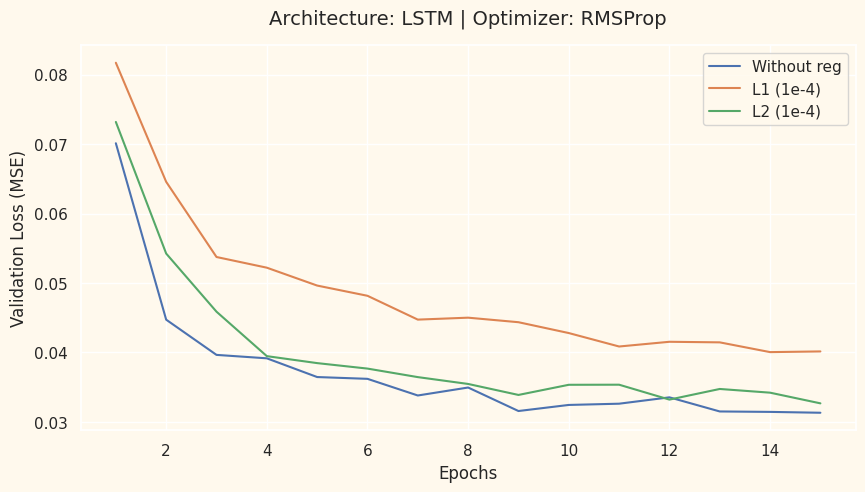

LSTM | Adam | Without reg
LSTM | Adam | L1 (1e-4)
LSTM | Adam | L2 (1e-4)


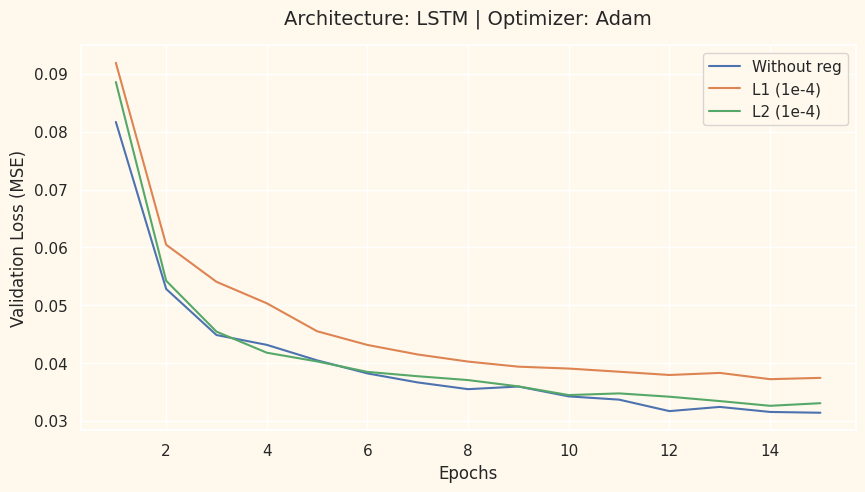

GRU | SGD | Without reg
GRU | SGD | L1 (1e-4)
GRU | SGD | L2 (1e-4)


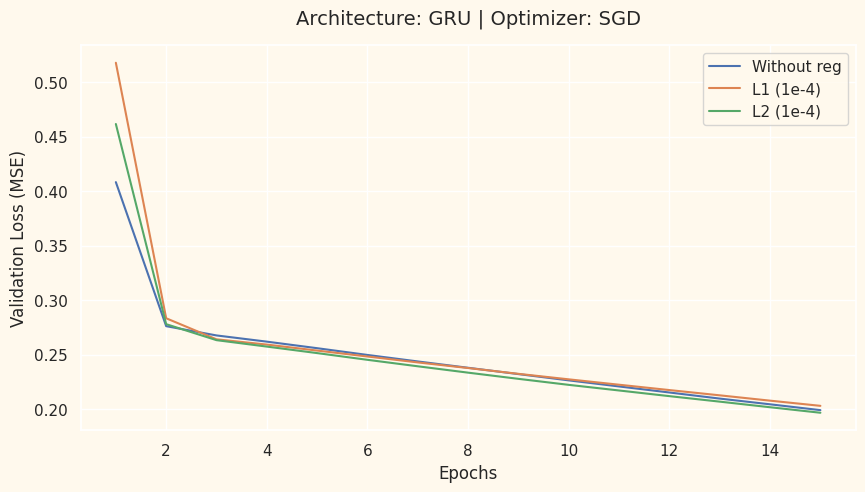

GRU | Momentum | Without reg
GRU | Momentum | L1 (1e-4)
GRU | Momentum | L2 (1e-4)


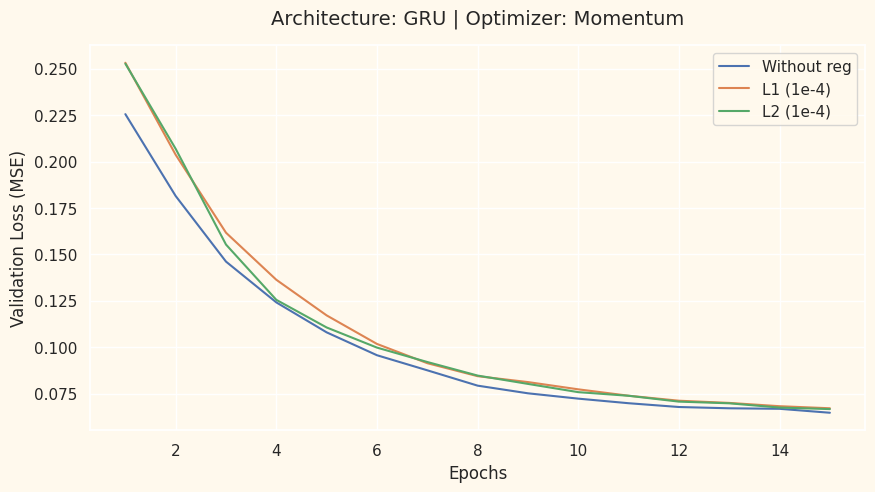

GRU | RMSProp | Without reg
GRU | RMSProp | L1 (1e-4)
GRU | RMSProp | L2 (1e-4)


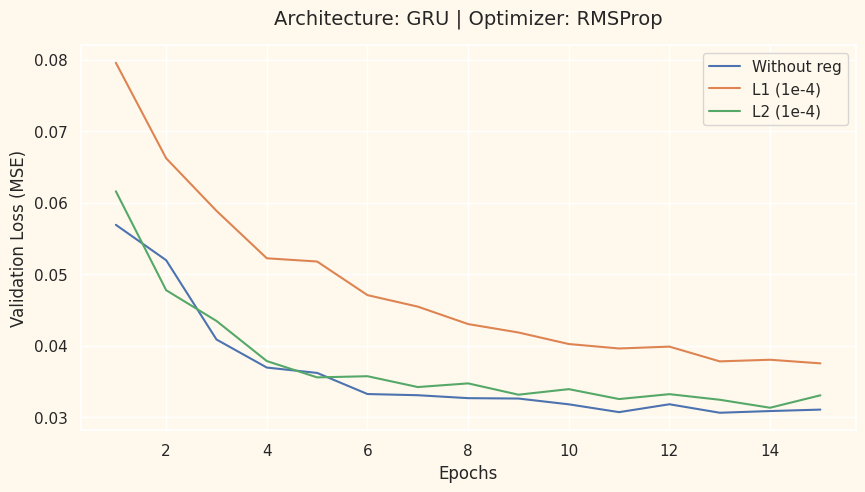

GRU | Adam | Without reg
GRU | Adam | L1 (1e-4)
GRU | Adam | L2 (1e-4)


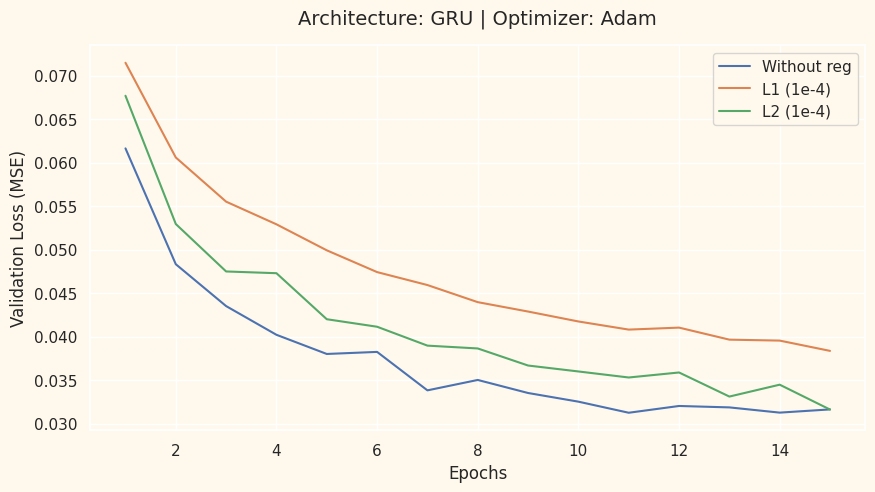

In [128]:
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

criterion = nn.MSELoss()

num_epochs = 15

architectures = {
    'LSTM': LSTMRegressor,
    'GRU': GRURegressor
}

optimizers_config = {
    'SGD': lambda params, wd: optim.SGD(params, lr=1e-3, weight_decay=wd),
    'Momentum': lambda params, wd: optim.SGD(params, lr=1e-3, momentum=0.9, weight_decay=wd),
    'RMSProp': lambda params, wd: optim.RMSprop(params, lr=1e-3, weight_decay=wd),
    'Adam': lambda params, wd: optim.Adam(params, lr=1e-3, weight_decay=wd)
}

regularizations =[
    ('Without reg', 0.0, 0.0),
    ('L1 (1e-4)', 1e-4, 0.0),
    ('L2 (1e-4)', 0.0, 1e-4)
]

results = []

for arch_name, ArchClass in architectures.items():
    for opt_name, opt_func in optimizers_config.items():

        plt.figure(figsize=(10, 5))
        plt.title(f"Architecture: {arch_name} | Optimizer: {opt_name}", fontsize=14, pad=15)

        for reg_name, l1_val, l2_val in regularizations:
            print(f"{arch_name} | {opt_name} | {reg_name}")

            model = ArchClass(input_size=input_size, hidden_size=64, num_layers=2, dropout=0.2).to(device)
            optimizer = opt_func(model.parameters(), l2_val)
            val_losses = []
            for epoch in range(num_epochs):
                train_loss = train(model, train_loader, criterion, optimizer, device, l1_lambda=l1_val)
                val_loss = val(model, val_loader, criterion, device)
                val_losses.append(val_loss)

            y_pred_scaled, y_test_scaled = predict(model, test_loader, device)
            y_pred = scaler_y.inverse_transform(y_pred_scaled)
            y_true = scaler_y.inverse_transform(y_test_scaled)

            mae = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))

            results.append({
                'Architecture': arch_name,
                'Optimizer': opt_name,
                'Reg': reg_name,
                'MAE': mae,
                'RMSE': rmse,
                'Val_Loss': val_losses[-1]
            })

            plt.plot(range(1, num_epochs + 1), val_losses, label=reg_name)

        plt.xlabel('Epochs')
        plt.ylabel('Validation Loss (MSE)')
        plt.legend()
        plt.grid(True)
        plt.show()

In [129]:
results_df = pd.DataFrame(results)

# по RMSE (меньше -> лучше)
best_results = results_df.sort_values('RMSE')

print(best_results.head(5))

best_config = best_results.iloc[0]
print(f"\nBest: {best_config['Architecture']} + {best_config['Optimizer']} + {best_config['Reg']}")


   Architecture Optimizer          Reg         MAE        RMSE  Val_Loss
9          LSTM      Adam  Without reg  224.622726  340.487208  0.031406
21          GRU      Adam  Without reg  227.639069  342.039848  0.031658
6          LSTM   RMSProp  Without reg  230.948242  347.050192  0.031325
23          GRU      Adam    L2 (1e-4)  229.245773  347.404877  0.031641
18          GRU   RMSProp  Without reg  237.319138  350.639015  0.031085

Best: LSTM + Adam + Without reg


In [130]:
'''
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


#optimizer = optim.SGD()

#for l2 регуляризации надо добавить weight_decay в оптимизатор.
#optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay = 1e-5)

#l1 добавляется вручную в функции train, т.е. прибавляем абсолютное значение весов к лоссу

num_epochs = 15

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, criterion, optimizer, device)
    val_loss = val(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")
'''

'\nimport torch.optim as optim\n\ncriterion = nn.MSELoss()\noptimizer = optim.Adam(model.parameters(), lr=1e-3)\n\n\n#optimizer = optim.SGD()\n\n#for l2 регуляризации надо добавить weight_decay в оптимизатор.\n#optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay = 1e-5)\n\n#l1 добавляется вручную в функции train, т.е. прибавляем абсолютное значение весов к лоссу\n\nnum_epochs = 15\n\ntrain_losses = []\nval_losses = []\n\nfor epoch in range(num_epochs):\n    train_loss = train(model, train_loader, criterion, optimizer, device)\n    val_loss = val(model, val_loader, criterion, device)\n\n    train_losses.append(train_loss)\n    val_losses.append(val_loss)\n\n    print(f"Epoch {epoch+1:02d}/{num_epochs} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")\n'

In [131]:
y_pred_scaled, y_test_scaled = predict(model, test_loader, device)

In [132]:
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test_scaled)

In [133]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 229.2457733154297
RMSE: 347.4048768188207
R2  : 0.9693377017974854


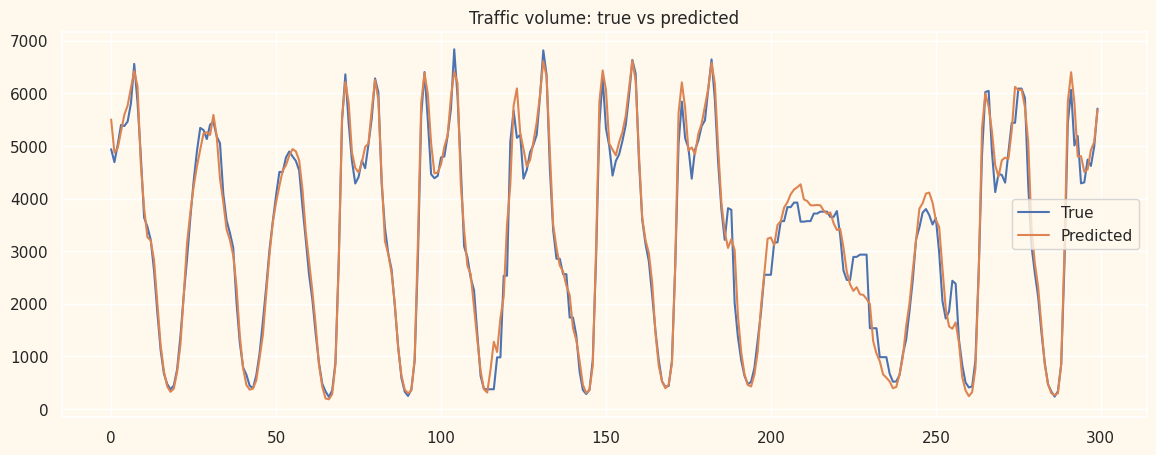

In [134]:
plt.figure(figsize=(14, 5))
plt.plot(y_true[:300], label='True')
plt.plot(y_pred[:300], label='Predicted')
plt.legend()
plt.title('Traffic volume: true vs predicted')
plt.show()

In [135]:
def last_hour_baseline(X, feature_cols, scaler_y):
    traffic_idx = feature_cols.index('traffic_volume')
    y_pred_scaled = X[:, -1, traffic_idx].reshape(-1, 1)
    return scaler_y.inverse_transform(y_pred_scaled)

In [136]:
y_pred_baseline = last_hour_baseline(X_test, feature_cols, scaler_y)
y_true = scaler_y.inverse_transform(y_test)

mae_baseline = mean_absolute_error(y_true, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred_baseline))
r2_baseline = r2_score(y_true, y_pred_baseline)

print("Baseline (last hour)")
print("MAE :", mae_baseline)
print("RMSE:", rmse_baseline)
print("R2  :", r2_baseline)

Baseline (last hour)
MAE : 486.0120715970584
RMSE: 740.2607180998864
R2  : 0.8607796465762283


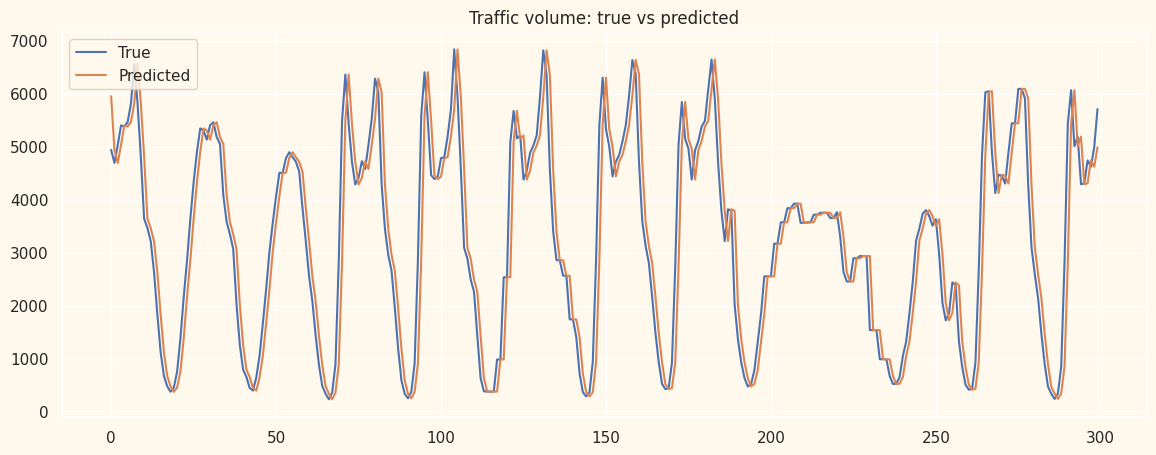

In [137]:
plt.figure(figsize=(14, 5))
plt.plot(y_true[:300], label='True')
plt.plot(y_pred_baseline[:300], label='Predicted')
plt.legend()
plt.title('Traffic volume: true vs predicted')
plt.show()

In [138]:
def last_day_baseline(X, feature_cols, scaler_y):
    traffic_idx = feature_cols.index('traffic_volume')
    y_pred_scaled = X[:, 0, traffic_idx].reshape(-1, 1)
    return scaler_y.inverse_transform(y_pred_scaled)

In [139]:
y_pred_baseline_last_day = last_day_baseline(X_test, feature_cols, scaler_y)
y_true = scaler_y.inverse_transform(y_test)

mae_baseline = mean_absolute_error(y_true, y_pred_baseline_last_day)
rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred_baseline_last_day))
r2_baseline = r2_score(y_true, y_pred_baseline_last_day)

print("Baseline (last hour)")
print("MAE :", mae_baseline)
print("RMSE:", rmse_baseline)
print("R2  :", r2_baseline)

Baseline (last hour)
MAE : 1559.864437352574
RMSE: 2203.80308289263
R2  : -0.2338969652591112


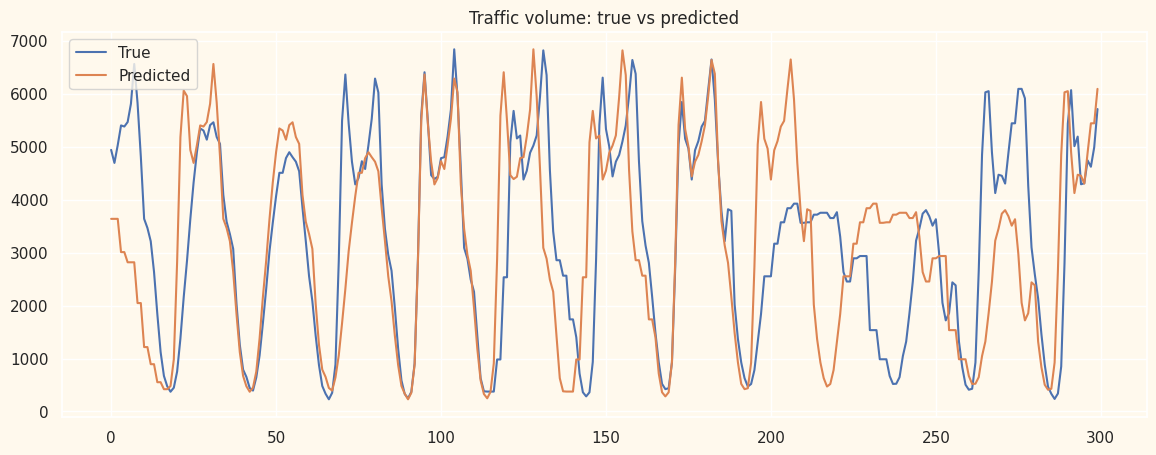

In [140]:
plt.figure(figsize=(14, 5))
plt.plot(y_true[:300], label='True')
plt.plot(y_pred_baseline_last_day[:300], label='Predicted')
plt.legend()
plt.title('Traffic volume: true vs predicted')
plt.show()

grid search


In [141]:
import copy
import itertools

In [142]:
def get_loss_function(loss_name):
    if loss_name == 'mse':
        return nn.MSELoss()
    elif loss_name == 'mae':
        return nn.L1Loss()
    elif loss_name == 'huber':
        return nn.HuberLoss(delta=1.0)
    else:
        raise ValueError(f'Unknown loss: {loss_name}')

In [143]:
def make_loaders(X_train, y_train, X_val, y_val, batch_size):
    train_dataset = TrafficDataset(X_train, y_train)
    val_dataset = TrafficDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

In [144]:
def train_model_with_params(
    X_train, y_train,
    X_val, y_val,
    input_size,
    device,
    params,
    max_epochs=20,
    patience=5
):
    train_loader, val_loader = make_loaders(
        X_train, y_train, X_val, y_val, params['batch_size']
    )

    model = LSTMRegressor(
        input_size=input_size,
        hidden_size=params['hidden_size'],
        num_layers=params['num_layers'],
        dropout=params['dropout']
    ).to(device)

    criterion = get_loss_function(params['loss_name'])
    optimizer = optim.Adam(model.parameters(), lr=params['lr'])

    best_val_loss = float('inf')
    best_state = None
    best_epoch = 0
    patience_counter = 0

    history = {
        'train_loss': [],
        'val_loss': []
    }

    for epoch in range(max_epochs):
        train_loss = train(model, train_loader, criterion, optimizer, device)
        val_loss = val(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    model.load_state_dict(best_state)

    return {
        'model': model,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'history': history,
        'params': params
    }

In [145]:
param_grid = {
    'hidden_size': [64, 96, 128],
    'num_layers': [1, 2],
    'dropout': [0.0, 0.2],
    'lr': [1e-3, 5e-4],
    'batch_size': [64, 128],
    'loss_name': ['huber']
}

In [146]:
def expand_grid(param_grid):
    keys = list(param_grid.keys())
    values = list(param_grid.values())

    combinations = []
    for combination in itertools.product(*values):
        combinations.append(dict(zip(keys, combination)))

    return combinations

In [147]:
all_params = expand_grid(param_grid)
len(all_params)

48

In [95]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = X_train.shape[2]

results = []
best_run = None
best_score = float('inf')

for i, params in enumerate(all_params, start=1):
    print(f"\n[{i}/{len(all_params)}] params = {params}")

    run_result = train_model_with_params(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        input_size=input_size,
        device=device,
        params=params,
        max_epochs=20,
        patience=5
    )

    row = params.copy()
    row['best_val_loss'] = run_result['best_val_loss']
    row['best_epoch'] = run_result['best_epoch']
    results.append(row)

    print(
        f"best_val_loss = {run_result['best_val_loss']:.6f}, "
        f"best_epoch = {run_result['best_epoch']}"
    )

    if run_result['best_val_loss'] < best_score:
        best_score = run_result['best_val_loss']
        best_run = run_result


[1/48] params = {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 64, 'loss_name': 'huber'}
best_val_loss = 0.016864, best_epoch = 18

[2/48] params = {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 128, 'loss_name': 'huber'}
best_val_loss = 0.030048, best_epoch = 5

[3/48] params = {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.0005, 'batch_size': 64, 'loss_name': 'huber'}
best_val_loss = 0.016429, best_epoch = 19

[4/48] params = {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.0005, 'batch_size': 128, 'loss_name': 'huber'}
best_val_loss = 0.019761, best_epoch = 18

[5/48] params = {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 64, 'loss_name': 'huber'}
best_val_loss = 0.016809, best_epoch = 20

[6/48] params = {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 128, 'loss_name': 'huber'}
best_val_loss = 0.024837, best_epoch = 6

[7/48]

In [96]:
results_df = pd.DataFrame(results).sort_values('best_val_loss').reset_index(drop=True)
results_df.head(10)

,hidden_size,num_layers,dropout,lr,batch_size,loss_name,best_val_loss,best_epoch
0,64,2,0.2,0.0010,64,huber,0.015178,18
1,128,2,0.2,0.0005,64,huber,0.015339,17
2,96,2,0.2,0.0005,64,huber,0.015361,19
3,96,2,0.2,0.0010,64,huber,0.015450,14
4,128,2,0.2,0.0010,64,huber,0.015496,20
5,64,2,0.0,0.0010,64,huber,0.015605,13
6,64,2,0.2,0.0005,64,huber,0.015656,19
7,128,2,0.0,0.0010,64,huber,0.015771,17
8,64,2,0.0,0.0005,64,huber,0.015784,18
9,128,2,0.2,0.0005,128,huber,0.015894,20


In [97]:
print("Best params:")
print(best_run['params'])
print("Best val loss:", best_run['best_val_loss'])
print("Best epoch:", best_run['best_epoch'])

Best params:
{'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 64, 'loss_name': 'huber'}
Best val loss: 0.01517796459861871
Best epoch: 18


In [98]:
test_loader = DataLoader(
    TrafficDataset(X_test, y_test),
    batch_size=best_run['params']['batch_size'],
    shuffle=False
)

y_pred_scaled, y_test_scaled = predict(best_run['model'], test_loader, device)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test_scaled)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("Best model on TEST")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

Best model on TEST
MAE : 226.8134002685547
RMSE: 347.03415267809015
R2  : 0.969403088092804


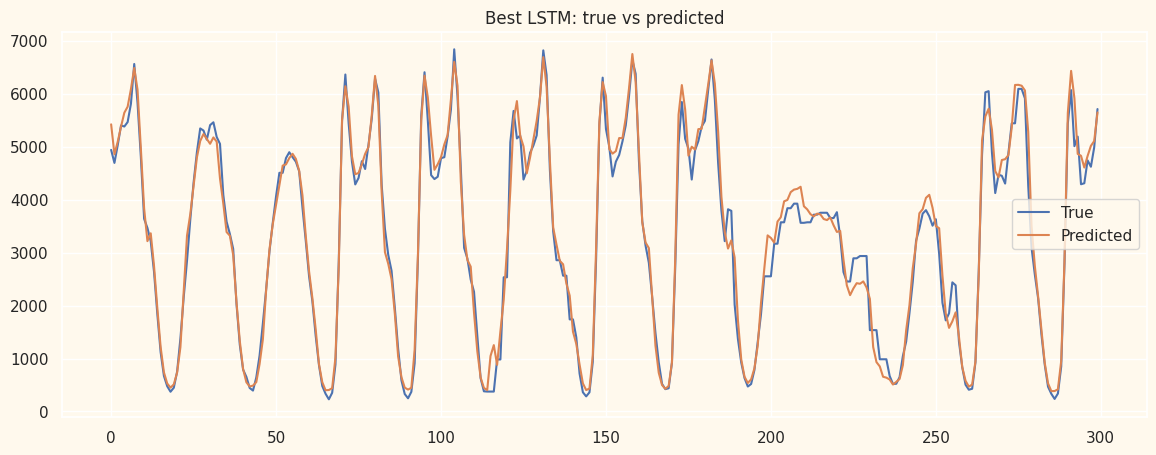

In [99]:
plt.figure(figsize=(14, 5))
plt.plot(y_true[:300], label='True')
plt.plot(y_pred[:300], label='Predicted')
plt.legend()
plt.title('Best LSTM: true vs predicted')
plt.show()

In [100]:
@torch.no_grad()
def recursive_predict_test(
    model,
    test_X_tab,
    test_df,
    feature_cols,
    target,
    window_size,
    scaler_X,
    scaler_y,
    device
):
    model.eval()

    traffic_idx = feature_cols.index('traffic_volume')

    # копия тестовых признаков, которую будем постепенно портить своими прогнозами
    X_roll = test_X_tab.copy()

    preds_scaled_y = []

    # идём по времени: предсказываем точку t по окну [t-window_size, ..., t-1]
    for t in range(window_size, len(X_roll)):
        window = X_roll[t - window_size:t]  # shape: (window_size, n_features)
        window_tensor = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)

        pred_scaled_y = model(window_tensor).cpu().numpy()[0, 0]
        preds_scaled_y.append(pred_scaled_y)

        # переводим прогноз из шкалы y в реальные значения
        pred_real = scaler_y.inverse_transform([[pred_scaled_y]])[0, 0]

        # теперь переводим это же значение в шкалу X для столбца traffic_volume
        pred_scaled_x = (pred_real - scaler_X.mean_[traffic_idx]) / scaler_X.scale_[traffic_idx]

        # подменяем traffic_volume в текущей строке t,
        # чтобы на следующих шагах модель использовала уже свой прогноз
        X_roll[t, traffic_idx] = pred_scaled_x

    preds_scaled_y = np.array(preds_scaled_y).reshape(-1, 1)

    # истинные значения цели для сравнения
    y_true_real = test_df[target].iloc[window_size:].values.reshape(-1, 1)

    # предсказания в реальной шкале
    y_pred_real = scaler_y.inverse_transform(preds_scaled_y)

    return y_true_real, y_pred_real

In [101]:
y_true_recursive, y_pred_recursive = recursive_predict_test(
    model=model,
    test_X_tab=test_X_tab,
    test_df=test_df,
    feature_cols=feature_cols,
    target=target,
    window_size=window_size,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    device=device
)

In [102]:
mae_recursive = mean_absolute_error(y_true_recursive, y_pred_recursive)
rmse_recursive = np.sqrt(mean_squared_error(y_true_recursive, y_pred_recursive))
r2_recursive = r2_score(y_true_recursive, y_pred_recursive)

print("Recursive TEST (using previous predictions)")
print("MAE :", mae_recursive)
print("RMSE:", rmse_recursive)
print("R2  :", r2_recursive)

Recursive TEST (using previous predictions)
MAE : 423.9705810546875
RMSE: 663.7209739416105
R2  : 0.8880808353424072


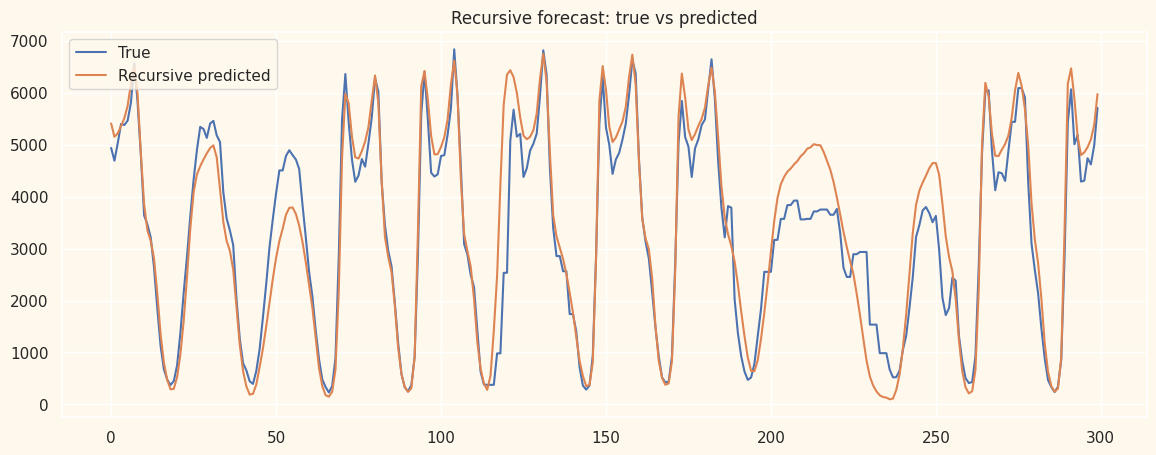

In [103]:
plt.figure(figsize=(14, 5))
plt.plot(y_true_recursive[:300], label='True')
plt.plot(y_pred_recursive[:300], label='Recursive predicted')
plt.legend()
plt.title('Recursive forecast: true vs predicted')
plt.show()